In [29]:
# Importing required libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

plt.style.use("default")

sns.set_theme(style="whitegrid")

pd.set_option("display.max_columns", None)

In [30]:
# Loading Data

fund_master = pd.read_csv("../data/processed/fund_master_clean.csv")

nav = pd.read_csv("../data/processed/nav_history_clean.csv")

aum = pd.read_csv("../data/processed/aum_by_fund_house_clean.csv")

sip = pd.read_csv("../data/processed/monthly_sip_inflows_clean.csv")

category = pd.read_csv("../data/processed/category_inflows_clean.csv")

folio = pd.read_csv("../data/processed/industry_folio_count_clean.csv")

performance = pd.read_csv("../data/processed/scheme_performance_clean.csv")

transactions = pd.read_csv("../data/processed/investor_transactions_clean.csv")

portfolio = pd.read_csv("../data/processed/portfolio_holdings_clean.csv")

benchmark = pd.read_csv("../data/processed/benchmark_indices_clean.csv")

In [31]:
# Nav trend analysis

nav["date"] = pd.to_datetime(nav["date"])

fig = px.line(
    nav,
    x="date",
    y="nav",
    color="amfi_code",
    title="Daily NAV Trend (2022-2026)"
)

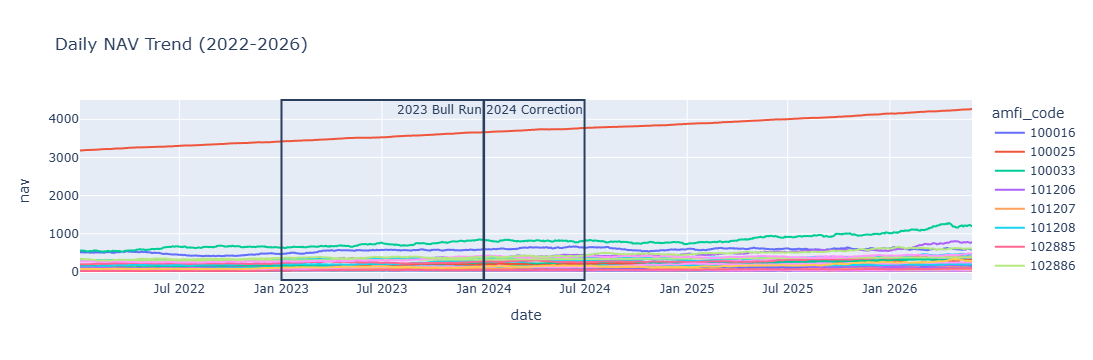

In [32]:
fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    annotation_text="2023 Bull Run"
)

fig.add_vrect(
    x0="2024-01-01",
    x1="2024-06-30",
    annotation_text="2024 Correction"
)

2023 witnessed a broad-based NAV appreciation across equity funds indicating a strong market rally.

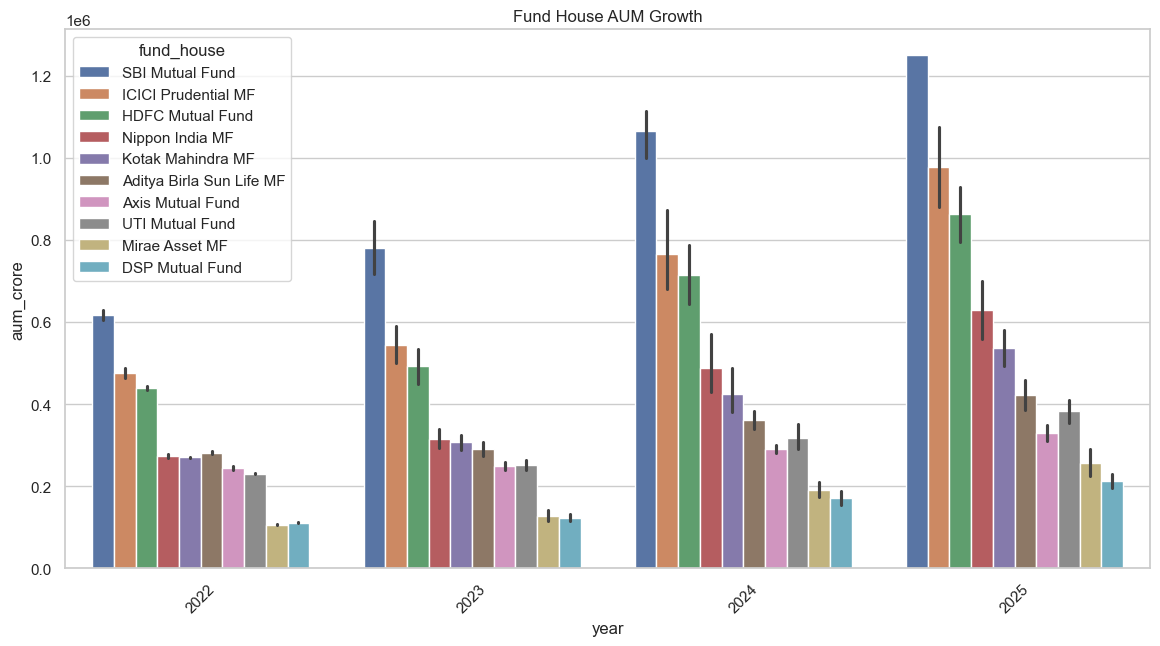

In [33]:
# AUM growth by fund house

aum["date"] = pd.to_datetime(aum["date"])
aum["year"] = aum["date"].dt.year

plt.figure(figsize=(14,7))

sns.barplot(
    data=aum,
    x="year",
    y="aum_crore",
    hue="fund_house"
)

plt.title(
    "Fund House AUM Growth"
)

plt.xticks(rotation=45)

plt.savefig(
    "../reports/chart_02.png",
    dpi=500,
    bbox_inches="tight"
)

plt.show()


SBI Mutual Fund maintained industry leadership with AUM exceeding ₹12.5 lakh crore.

In [34]:
# 3 monthly SIP inflows

sip["month"] = pd.to_datetime(
    sip["month"]
)

fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    markers=True,
    title="Monthly SIP Inflows"
)

fig.add_annotation(
    x="2025-12-01",
    y=31002,
    text="₹31,002 Cr"
)
fig.write_image(
    "../reports/chart_03.png"
)

SIP inflows reached an all-time high of ₹31,002 crore in December 2025.

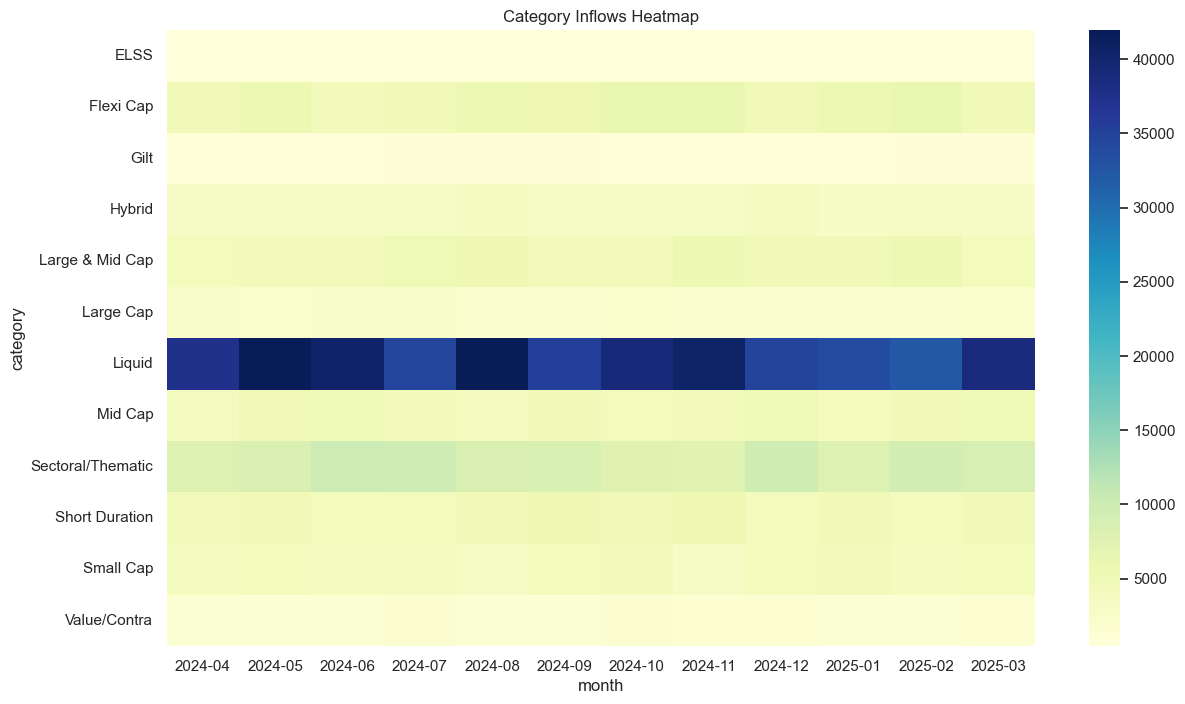

In [35]:
# 4. category inflow heatmap

pivot = category.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

plt.figure(figsize=(14,8))

sns.heatmap(
    pivot,
    cmap="YlGnBu"
)

plt.title(
    "Category Inflows Heatmap"
)
plt.savefig(
    "../reports/chart_04.png",
    dpi=500,
    bbox_inches="tight"
)
plt.show()

Equity-oriented categories consistently attracted stronger inflows than debt categories.

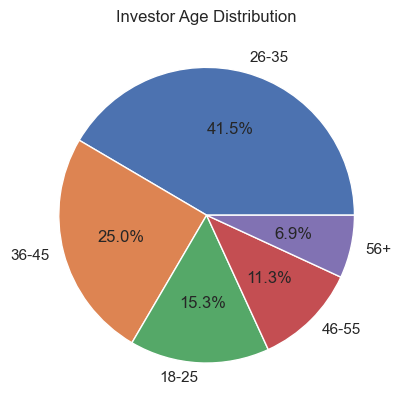

In [36]:
# 5. Age group distribution

transactions["age_group"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title(
    "Investor Age Distribution"
)
plt.savefig(
    "../reports/chart_05.png",
    dpi=500,
    bbox_inches="tight"
)
plt.show()

Investors aged 26–35 constitute the largest share of mutual fund participation.

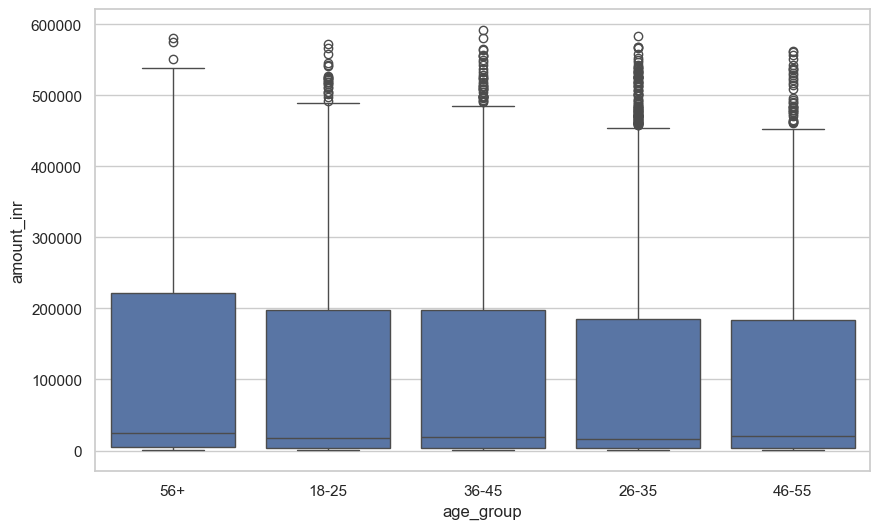

In [37]:
# 6. sip amount boxplot

plt.figure(figsize=(10,6))

sns.boxplot(
    data=transactions,
    x="age_group",
    y="amount_inr"
)
plt.savefig(
    "../reports/chart_06.png",
    dpi=500,
    bbox_inches="tight"
)
plt.show()

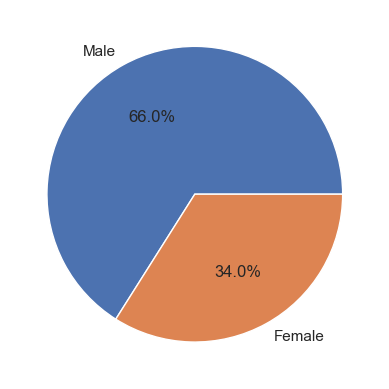

In [38]:
# 7. gender split 

transactions["gender"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)
plt.savefig(
    "../reports/chart_07.png",
    dpi=500,
    bbox_inches="tight"
)
plt.show()

As an overall 66% investors are male category
Male investors represent the majority of transaction volume in the dataset.

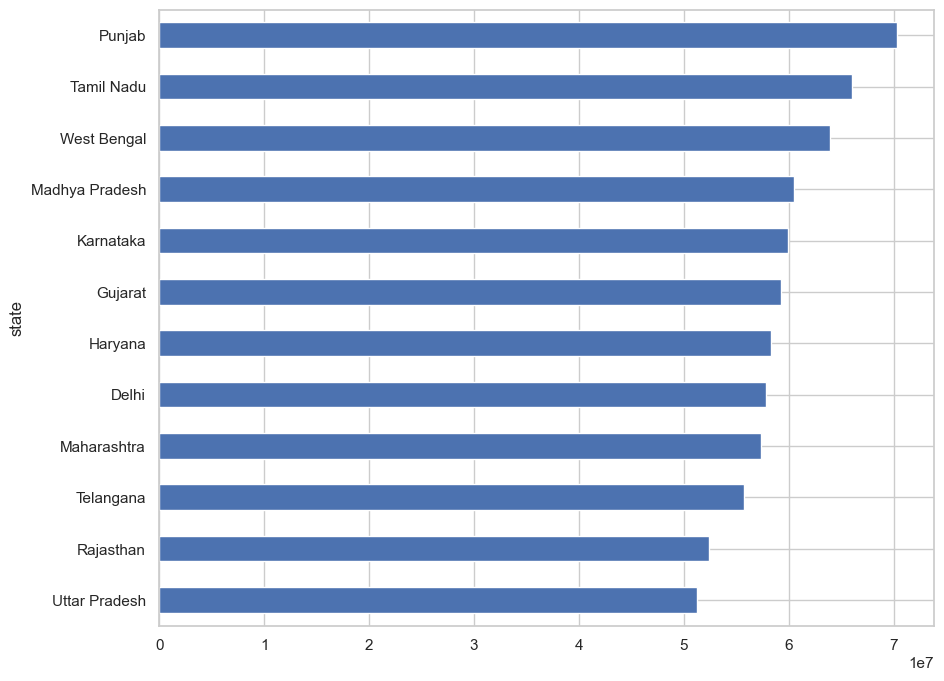

In [39]:
#8. state wise SIP Amount

state_amt = (
    transactions
    .groupby("state")["amount_inr"]
    .sum()
    .sort_values()
)

state_amt.plot(
    kind="barh",
    figsize=(10,8)
)
plt.savefig(
    "../reports/chart_08.png",
    dpi=500,
    bbox_inches="tight"
)
plt.show()

Punjab and Tamilnadu contribute the highest SIP investment volumes.

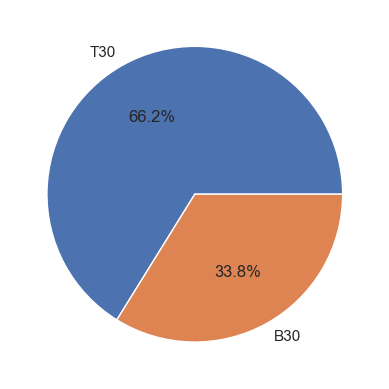

In [40]:
#9. T30 vs B30
transactions["city_tier"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)
plt.savefig(
    "../reports/chart_09.png",
    dpi=500,
    bbox_inches="tight"
)
plt.show()

T30 cities dominate transaction activity, but B30 participation is steadily increasing.

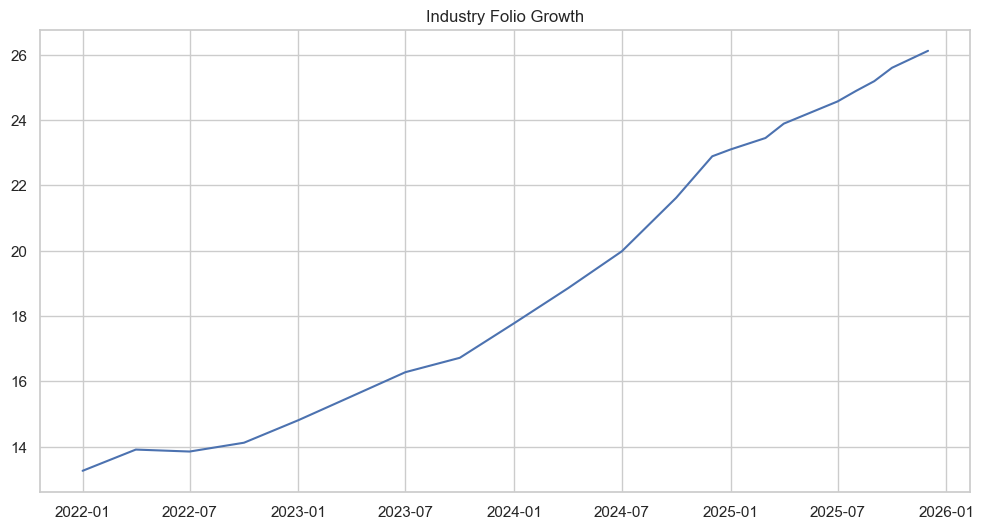

In [41]:
#10. Folio Growth 

folio["month"] = pd.to_datetime(
    folio["month"]
)

plt.figure(figsize=(12,6))

plt.plot(
    folio["month"],
    folio["total_folios_crore"]
)

plt.title(
    "Industry Folio Growth"
)
plt.savefig(
    "../reports/chart_10.png",
    dpi=500,
    bbox_inches="tight"
)
plt.show()

Industry folios nearly doubled from 13.26 crore to over 26 crore between 2022 and 2025.

In [42]:
# 11. Return correlation matrix 
#select top 10 schemes

pivot = nav.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

returns = pivot.pct_change()

corr = returns.corr()

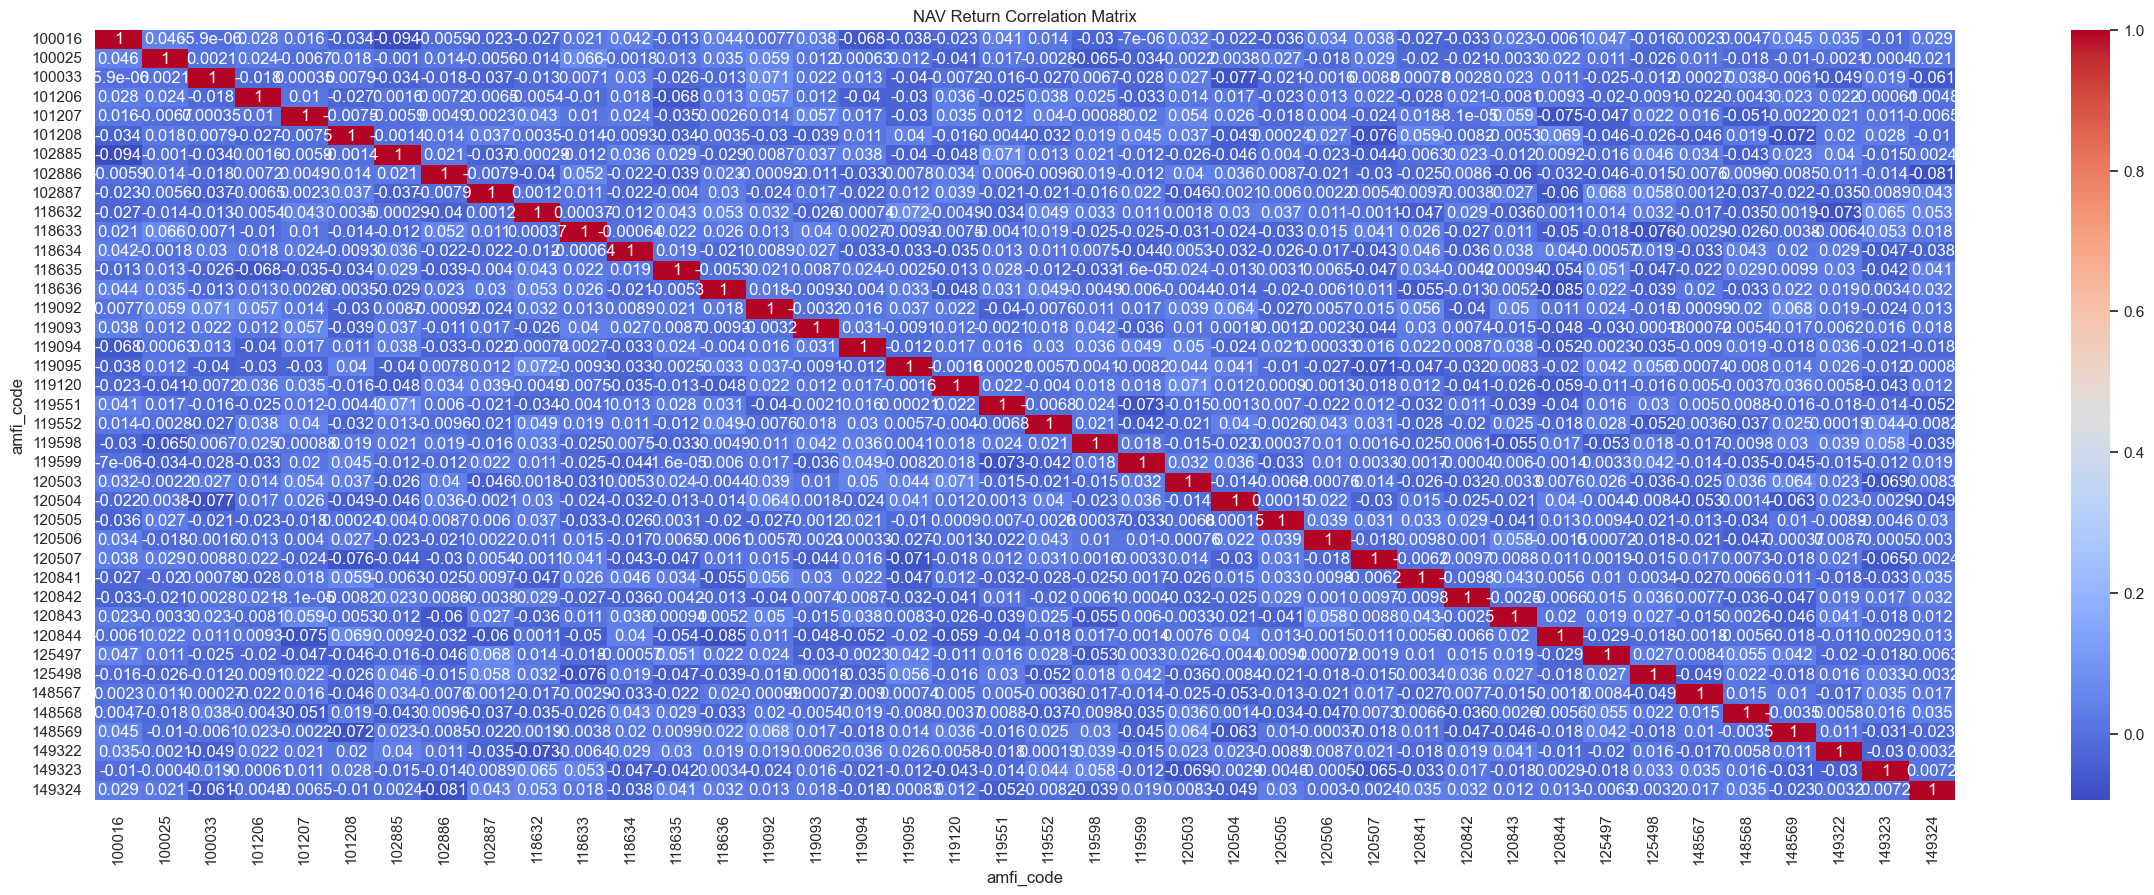

In [43]:
plt.figure(figsize=(30,10))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title(
    "NAV Return Correlation Matrix"
)
plt.savefig(
    "../reports/chart_11.png",
    dpi=800,
    bbox_inches="tight"
)
plt.show()

Large-cap funds exhibit strong positive correlation, reflecting common market exposure.

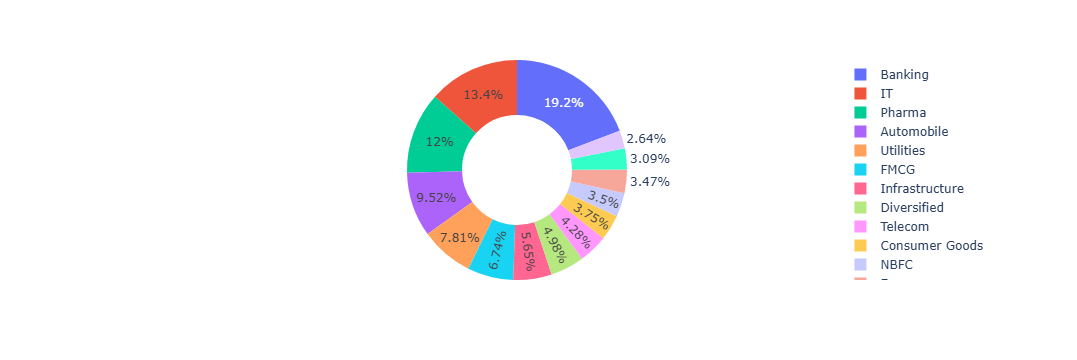

<Figure size 640x480 with 0 Axes>

In [48]:
# Sector Allocation Donut

sector = (
    portfolio
    .groupby("sector")["weight_pct"]
    .sum()
    .reset_index()
)

fig = px.pie(
    sector,
    names="sector",
    values="weight_pct",
    hole=0.5
)
plt.savefig(
    "../reports/chart_12.png",
    dpi=700,
    bbox_inches="tight"
)
fig.show()

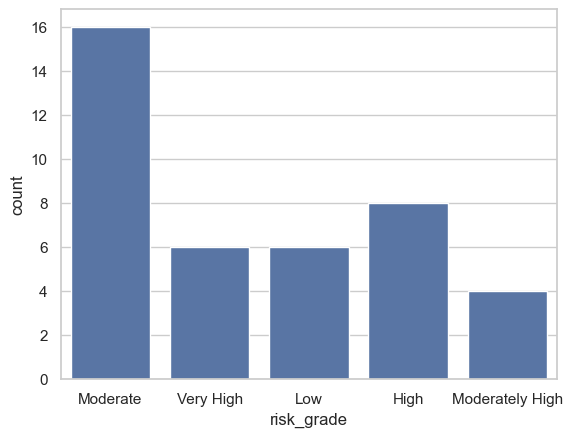

In [49]:
# Risk Grade Distribution
sns.countplot(
    data=performance,
    x="risk_grade"
)
fig.write_image(
    "../reports/chart_13.png"
)

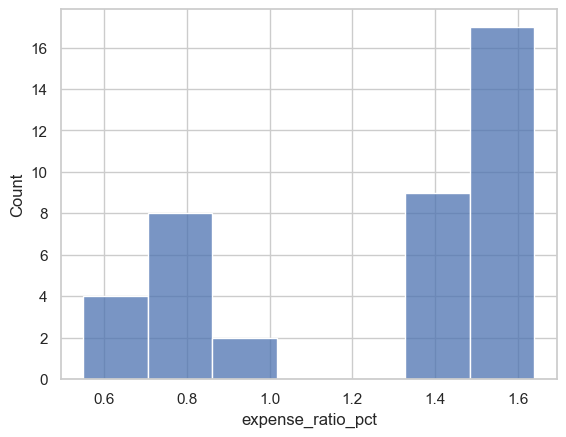

In [46]:
# Expense Ratio Distribution

sns.histplot(
    performance["expense_ratio_pct"]
)
fig.write_image(
    "../reports/chart_14.png"
)

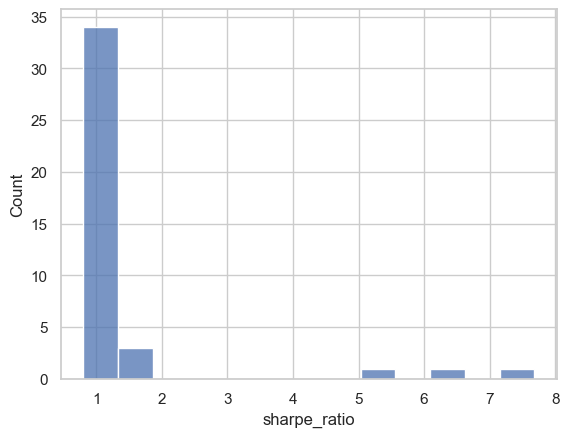

In [47]:
# Sharpe Ratio Distribution

sns.histplot(
    performance["sharpe_ratio"]
)
fig.write_image(
    "../reports/chart_15.png"
)